# AI usage

# Compulsory work description

# Links
- GitHub repository: https://github.com/xoksy/jouyit_IND320 
- streamlit app: https://jouyitind320.streamlit.app/

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#I create a variable to store the path to the data folder
path = r'C:\Users\matth\Desktop\NMBU\IND320\projet\jouyit_IND320\data'

In [2]:
#Reading the csv, watching how it looks like and searching for missing values
reservoirs = pd.read_csv(path + '\\reservoirs.csv')
print(reservoirs.head())
print(reservoirs.isna().sum())

      dato_Id omrType  omrnr  iso_aar  iso_uke  fyllingsgrad  kapasitet_TWh  \
0  1995-09-03      EL      4     1995       35      0.944721      21.079208   
1  2020-11-15      EL      1     2020       46      0.974361       6.003264   
2  2011-08-28      EL      4     2011       34      0.786499      21.079208   
3  1998-07-05      EL      3     1998       27      0.793969       8.920932   
4  2011-03-27      EL      4     2011       12      0.300820      21.079208   

   fylling_TWh neste_Publiseringsdato  fyllingsgrad_forrige_uke  \
0    19.913979    0001-01-01T00:00:00                  0.936888   
1     5.849344    2020-11-25T13:00:00                  0.997406   
2    16.578772    0001-01-01T00:00:00                  0.787193   
3     7.082947    0001-01-01T00:00:00                  0.733812   
4     6.341054    0001-01-01T00:00:00                  0.311122   

   endring_fyllingsgrad  
0              0.007833  
1             -0.023046  
2             -0.000694  
3              0.0

In [3]:
#Renaming the columns with english names
reservoirs = reservoirs.rename(columns={
    "dato_Id": "date_id",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "filling_degree",
    "kapasitet_TWh": "capacity_TWh",
    "fylling_TWh": "filling_TWh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "filling_degree_previous_week",
    "endring_fyllingsgrad": "change_in_filling_degree"
})
#Verifying the data types of the columns
reservoirs.dtypes

date_id                             str
area_type                           str
area_number                       int64
iso_year                          int64
iso_week                          int64
filling_degree                  float64
capacity_TWh                    float64
filling_TWh                     float64
next_publication_date               str
filling_degree_previous_week    float64
change_in_filling_degree        float64
dtype: object

In [4]:
#Changing the data types of the columns to datetime for date_id and next_publication_date
reservoirs['date_id'] = pd.to_datetime(reservoirs['date_id'])
reservoirs['next_publication_date'] = pd.to_datetime(reservoirs['next_publication_date'])
#Putting NaT for the next_publication_date where the year is 1, as it is not a valid date
reservoirs.loc[reservoirs["next_publication_date"].dt.year == 1,"next_publication_date"] = pd.NaT
reservoirs.dtypes

date_id                         datetime64[us]
area_type                                  str
area_number                              int64
iso_year                                 int64
iso_week                                 int64
filling_degree                         float64
capacity_TWh                           float64
filling_TWh                            float64
next_publication_date           datetime64[us]
filling_degree_previous_week           float64
change_in_filling_degree               float64
dtype: object

In [5]:
#Result
reservoirs.head()

,date_id,area_type,area_number,iso_year,iso_week,filling_degree,capacity_TWh,filling_TWh,next_publication_date,filling_degree_previous_week,change_in_filling_degree
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,NaT,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25 13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,NaT,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,NaT,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,NaT,0.311122,-0.010301


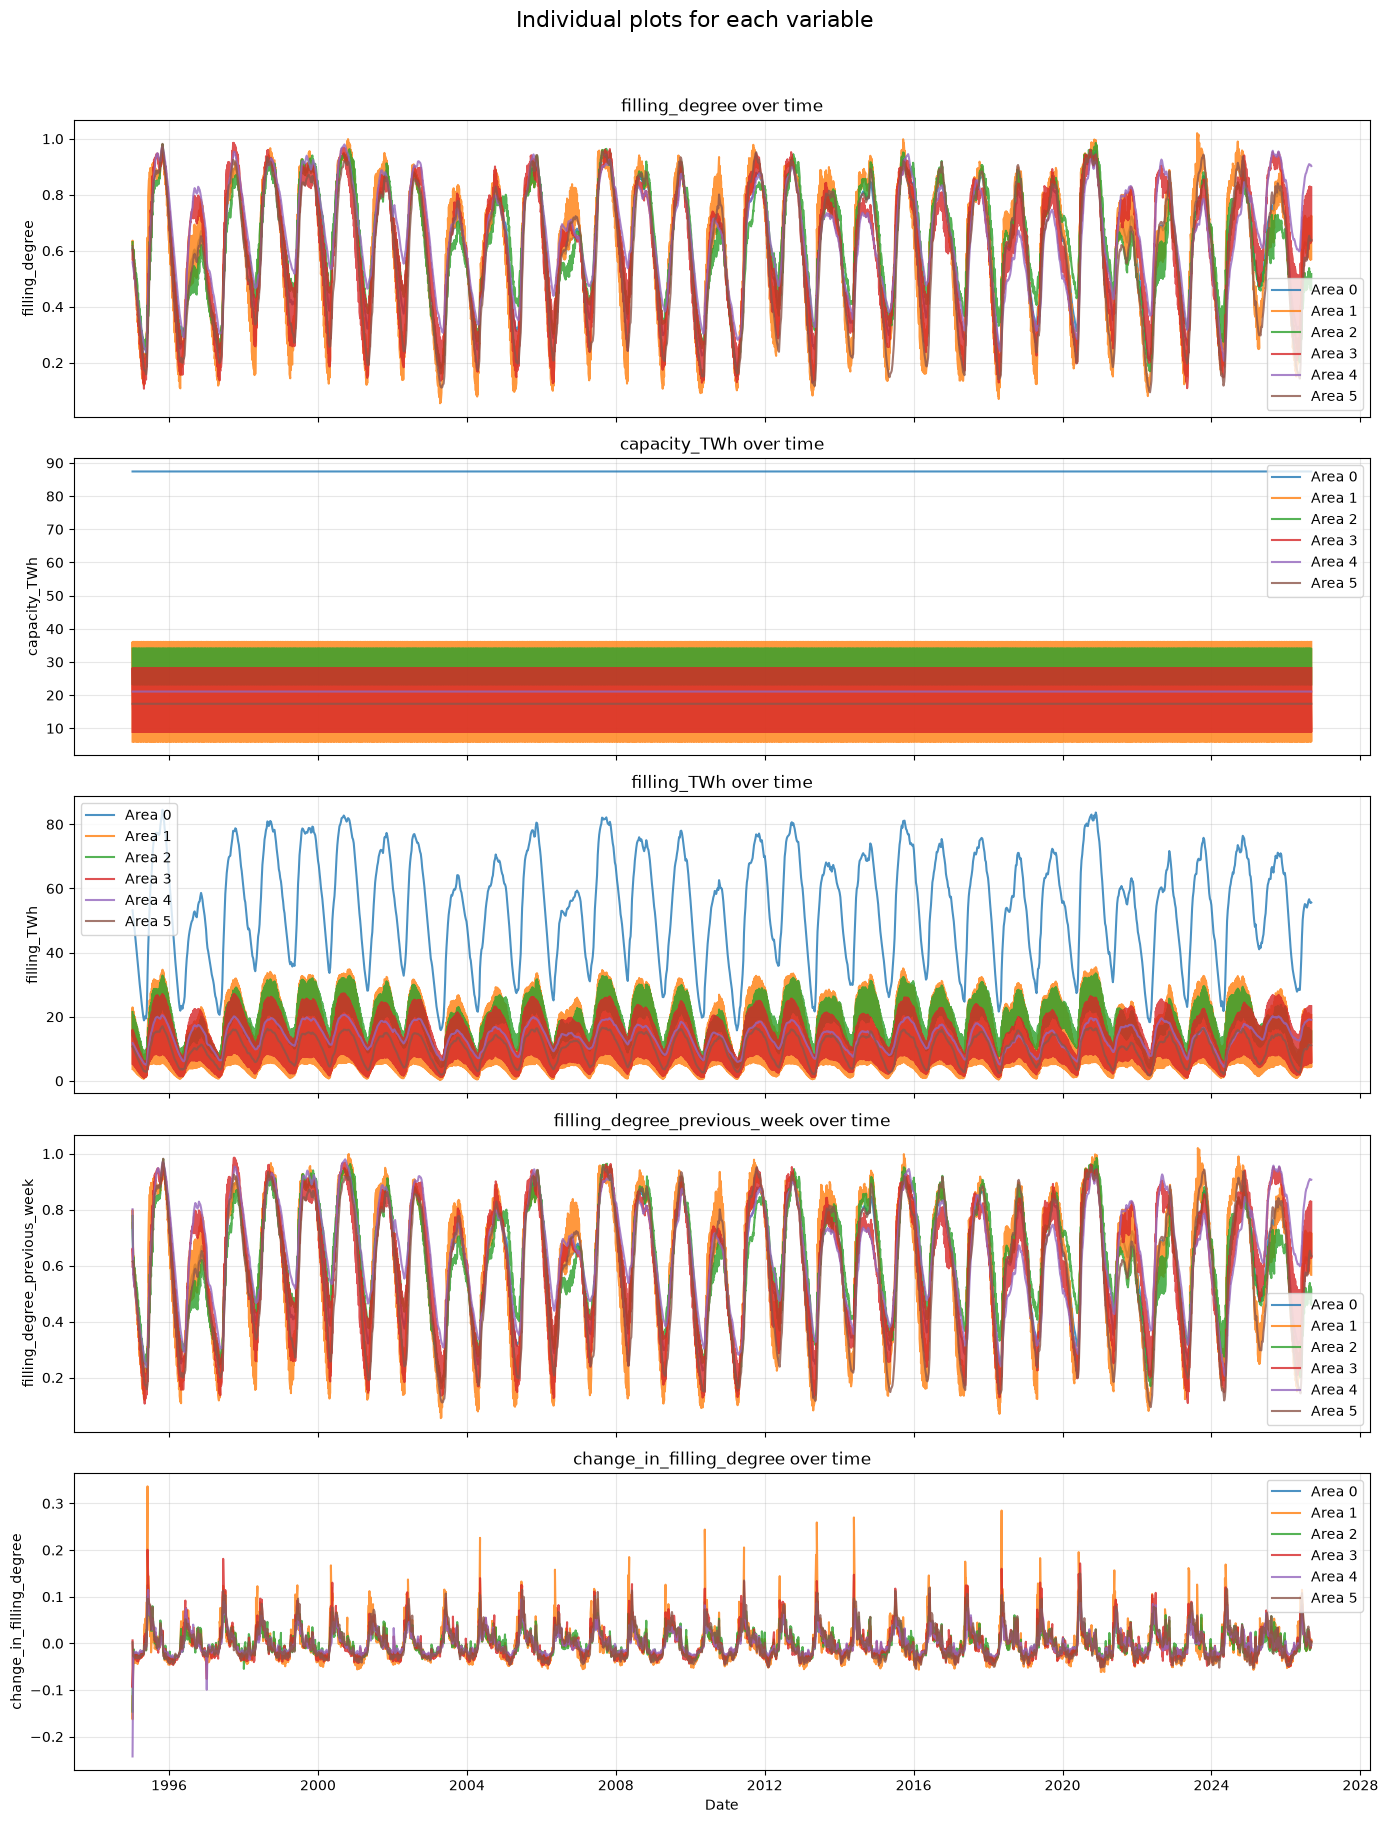

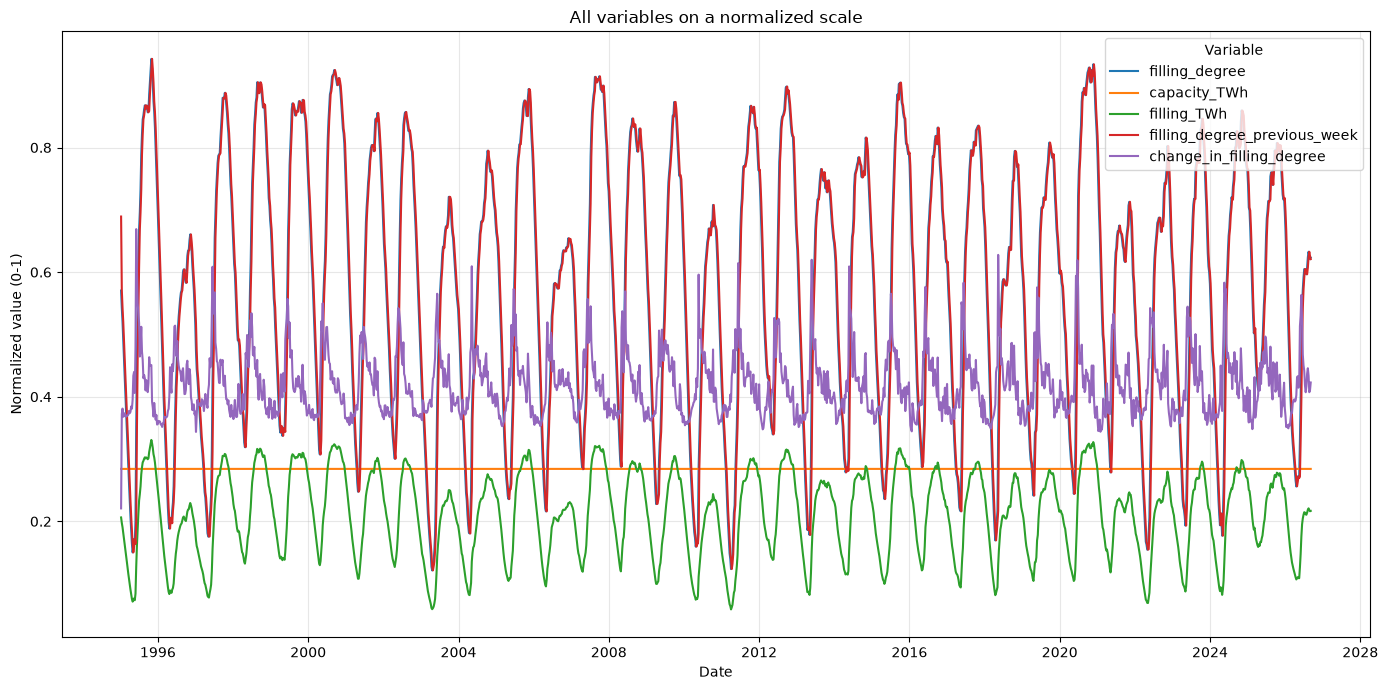

In [14]:
# Sort the data chronologically before plotting
reservoirs = reservoirs.sort_values("date_id")

plot_columns = [
    "filling_degree",
    "capacity_TWh",
    "filling_TWh",
    "filling_degree_previous_week",
    "change_in_filling_degree"
]

# Plot each variable separately
fig, axes = plt.subplots(
    nrows=len(plot_columns),
    ncols=1,
    figsize=(14, 18),
    sharex=True
)

for ax, column in zip(axes, plot_columns):
    for area_number, group in reservoirs.groupby("area_number"):
        ax.plot(
            group["date_id"],
            group[column],
            label=f"Area {area_number}",
            alpha=0.8
        )

    ax.set_title(f"{column} over time")
    ax.set_ylabel(column)
    ax.grid(alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Date")
fig.suptitle("Individual plots for each variable", fontsize=16, y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

# Normalize the variables to compare them on the same scale
normalized = reservoirs[plot_columns].apply(
    lambda column: (column - column.min()) /
                   (column.max() - column.min())
)

normalized["date_id"] = reservoirs["date_id"].values
normalized = normalized.groupby("date_id").mean()

plt.figure(figsize=(14, 7))

for column in plot_columns:
    plt.plot(
        normalized.index,
        normalized[column],
        label=column
    )

plt.title("All variables on a normalized scale")
plt.xlabel("Date")
plt.ylabel("Normalized value (0-1)")
plt.grid(alpha=0.3)
plt.legend(title="Variable")
plt.tight_layout()
plt.show()